# Example 4.1 - Experiment Class - QXAS - Bulk XAS Processing - Process Correlation - Interpolation - Export

    To reduce computation time for QXAS data analysis this example uses a pre-determined set of paramters (Example 4.0) to perform the following XAS analysis and process correlation steps:
    1. Data Import, Absoprtion Calcualtion, Data Cleanup
    2. Reference calibration and E0 determination
    3. Spectra Normalization
    4. Process Data Import, Correlation, and Export
    5. Spectra Interpolation and Export
    6. Save Experiment Object

    Note 1: This workflow only processes the sample spectra and not the reference
    Note 2: This workflow removes almsot all visualization of the data to increase computation time.
    
## Step 1. Import Modules

In [1]:
# File Handling
import os
import pickle

# Plot Handling
import matplotlib.pyplot as plt

# data handling
import numpy as np
import pandas as pd

# Make things interactive
import ipywidgets as widgets
from ipywidgets import interact, fixed, GridspecLayout
from IPython.display import display

# catXAS Handling:
os.chdir('..')
pwd = os.getcwd()
os.chdir('./catxas')
import general as fcts
import xas as xfcts
import plot as pfcts
import process
import experiment as exp

%matplotlib inline

## Step 2. Definitions

In [2]:
# Data Location Definitions:

# Folder containing ONLY XAS spectra
data_dir = os.path.join(pwd, 'sample data\Raw Data')

# Path to pickle object containing the pre-determined XAS processing parameterts:
param_path = os.path.join(pwd, 'sample results', 'qxas batch params.pickle')

# Mass Spec File (full path):
MS_filename = os.path.join(pwd, 'sample data\SnO2_TPR_MS.csv') 

# AmP LabView File (full path):
LV_filename = os.path.join(pwd, 'sample data\SnO2_TPR_LV.txt')

In [3]:
# Output Definitions: 

# Unique name for the experiment
exp_name = 'SnO2_TPR'

# Directory where to save the experiment:
pickle_dir = os.path.join(pwd, 'sample results')

# File name to save the sxperiment (must include extension '.pickle')
pickle_name = exp_name+'.pickle'

# Folder where results will be saved
output_dir = os.path.join(pwd, 'sample results')

# File name for saving spectra-process correlation data (extension can be left blank or .csv/.txt)
fname_correlation = exp_name+'_Process_Correlation'

# File name to save normalized and interpolated XAS spectra
fname_interpXAS = exp_name+'_NormXANES'

In [4]:
# Plotting Defs

Edge_Energy = 29200 # eV

emin = Edge_Energy-50 # eV

emax = Edge_Energy+50 # eV

## Step 3. Define Beamline Data Structure

Common data formats for SSRL beamlines can be found in the "BL specific XAS data structures.ipynb" notebook.

In [5]:
### Define the layout of the xas data file and how spectra are calcualted
xas_data_structure = {
    'time stamp': True,
    'time on line': 5,
    'time format': '# This Scan Create Date:\t%m/%d/%Y %I:%M:%S %p',
    'padded scan numbers': True,
    'column names': ['encoder', 'energy', 'adc_01', 'adc_02', 'adc_03', 'adc_04', 'adc_05', 'adc_06', 'adc_07', 'adc_08'],
    'energy column' : 'energy', # Energy [eV]
    'sample numerator': 'adc_01', # I0
    'sample denominator': 'adc_02', # I1
    'sample ln': True,
    'sample invert': False,
    'reference numerator': 'adc_02', # I1
    'reference denominator': 'adc_03', # I2
    'reference ln': True,
    'reference invert': False,
    'is QEXAFS': False
}

## Step 4. Import the Bulk Processing Parameters

In [6]:
pickle_in = open(param_path,"rb")
qxas_samp_params = pickle.load(pickle_in)
pickle_in.close()

print(qxas_samp_params)

{'delE': 1.0, 'e0': 29201.5237785261, 'pre1': -175, 'pre2': -100, 'norm1': 120, 'norm2': 900, 'nnorm': 2, 'make_flat': True}


## Step 5. Add Data to Experiment Object

In [7]:
# Create the Experimental Class
my_exp = exp.Experiment(exp_name)

# Add raw data into spectra files
my_exp.import_spectra(data_dir, xas_data_structure, ext = '.txt', print_name = False)

# Sanity Check to confirm data was imported
print(f"Number of XAS Spectra Imported: {len(my_exp.summary['XAS Spectra Files'])}")

Number of XAS Spectra Imported: 50


## Step 5. Clean up Data
    
#### STILL IN DEVELOPMENT

In [8]:
my_exp.organize_RawData(remove_duplicates=True, remove_nan_inf=False, remove_zeros=False, feedback=False, summary=True) # remove_nan_inf & remove_zeros does not work yet

Data Organized
Range of data points per raw spectra: 4980-4980
Range of data points after duplicates removed: 4838-4839
Range of data points after NaN/inf removed: 4980-4980
Range of data points after zeros removed: 4980-4980


## Step 6. Calculate Absorption Spectra

In [9]:
# Calcualte mux for Sample:
sample_spectra = True

# Calcualte mux for Reference:
ref_spectra = False

# Calculate Absorptoin Spectra
my_exp.calculate_spectra(sample_spectra = sample_spectra, ref_spectra = ref_spectra)

## Step 7. Remove BL data from experimental class

In [10]:
for key in my_exp.__dict__['spectra'].keys():
    my_exp.__dict__['spectra'][key].pop('BL Data')

## Step 8. Add the Bulk Processing Parameters to each Spectra

In [11]:
my_exp.load_params('mu Sample', qxas_samp_params)

## Step 9. Normalize Spectra

In [12]:
my_exp.normalize_spectra('mu Sample')

## Step 10. Add Process Data to Experiment, Correlate Process Parameters to XAS data, and Save Summary

    Note: Additiona datastreams will need their own functions. Please reach out with questions.

In [13]:
# Add Mass Spec Dataset
my_exp.import_massspec(MS_filename)

# Add LabView Dataset
my_exp.import_labview(LV_filename)

# Correlate Process Data
my_exp.correlate_process_params()

# Save Correlation Dataframe
my_exp.save_processparams(os.path.join(output_dir,fname_correlation))

Genearted Spectra Summary
Merged Index for Process: MS Data
Non-numeric columns found!
The following columns will be dropped during interpolation:
	SV1 SP
	SV1 Feedback
	SV2 SP
	SV2 Feedback
Merged Index for Process: LV Data
Process Parameter Data Saved


## Step 11. InterpolateXAS Spectra and Export Results

Interpolated Data Saved


<Axes: xlabel='energy'>

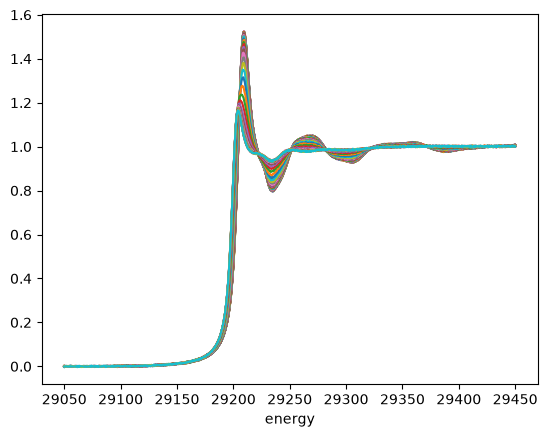

In [14]:
# Set the energy range and step size to interpolate onto
start = 29050
stop = 29450
step = 0.25

# Interpolate Spectra
my_exp.interpolate_spectra_E(start, stop, step, sample = 'mu Sample', mu = 'flat')

# Save Interpolated Spectra:
my_exp.save_interpXAS(os.path.join(output_dir,fname_interpXAS))

# Visualzie interpolated spectra with plot
my_exp.__dict__['summary']['Interpolated energy'].plot(legend=False)

## Step 12. Save Experiment with 'pickle'

In [15]:
pickle_path = os.path.join(pickle_dir,pickle_name)

pickle_out = open(pickle_path,"wb")
pickle.dump(my_exp, pickle_out)
pickle_out.close()